# Modern Parquet Paper Plot Demo

This notebook demonstrates the new analysis and paper-plotting path:

`Parquet epoch aggregates -> analysis helpers -> one curve per (agent_label, run_id) -> paper-style plot`

The example uses the checked-in smoke sweep under `results/reinforce_unified_demo`.

In [53]:
from pathlib import Path

from IPython.display import HTML
import matplotlib.pyplot as plt
import pandas as pd

from utils.analysis import (
    expand_policy_params,
    filter_epoch_rewards,
    inspect_epoch_rewards,
    last_epoch_table,
    load_epoch_rewards,
)
from utils.paper_plot import (
    AxesConfig,
    LegendConfig,
    SmoothingConfig,
    VarianceConfig,
    plot_learning_curves,
)

RESULT_ROOT = Path("results/reinforce_unified_demo")
RESULT_ROOT

PosixPath('results/reinforce_unified_demo')

## Inspect The Result Root

`inspect_epoch_rewards` gives a quick inventory of the run directory before loading or plotting.

In [54]:
inspection = inspect_epoch_rewards(RESULT_ROOT)

for key in ["rows", "columns", "epoch_min", "epoch_max", "agent_name", "agent_label", "policy_class", "run_id"]:
    if key in inspection:
        print(f"{key}: {inspection[key]}")

rows: 800
columns: ['run_id', 'config_hash', 'setup', 'global_seed', 'num_days', 'num_trajs', 'num_epochs', 'epoch', 'agent_name', 'agent_label', 'policy_class', 'policy_params_json', 'mean_reward', 'std_reward', 'n_trajs']
epoch_min: 0
epoch_max: 99
agent_name: ['baseline', 'learner']
agent_label: ['FixedBid|Bid=5|Limit=5', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-5', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-6', 'REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-5', 'REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-6']
policy_class: ['FixedBidPolicy', 'REINFORCE']
run_id: ['1bf1798b-6fe0-4cbb-9792-3810dab85d54', '4149740c-1885-42c8-a2cd-5f97bad20307', '6ff0d189-b6fe-4d10-9513-e67a630f17c4', 'f8936857-fc80-43bb-bf8d-fbf5e9551292']


## Load Epoch Aggregates

The canonical analysis input is still the Parquet row schema written by the runner: one row per `(run_id, epoch, agent)`.

In [55]:
df = load_epoch_rewards(RESULT_ROOT)
if "agent_label" not in df.columns:
    raise RuntimeError(
        "This result root uses the old label schema. Regenerate configs with "
        "pipeline.make_config_grid and rerun the sweep so Parquet rows include agent_label."
    )
print(df.shape)
df.head()

(800, 16)


,run_id,config_hash,setup,global_seed,num_days,num_trajs,num_epochs,epoch,agent_name,agent_label,policy_class,policy_params_json,mean_reward,std_reward,n_trajs,source_dir
0,4149740c-1885-42c8-a2cd-5f97bad20307,35bc47c0196e7761178c55a6346e53a90bcba350e0f6c8...,one_segment,123,1,100,100,0,learner,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,REINFORCE,"{""actor_final_activation"": ""relu"", ""actor_hidd...",-0.358445,0.097406,100,results/reinforce_unified_demo
1,4149740c-1885-42c8-a2cd-5f97bad20307,35bc47c0196e7761178c55a6346e53a90bcba350e0f6c8...,one_segment,123,1,100,100,0,baseline,FixedBid|Bid=5|Limit=5,FixedBidPolicy,"{""bid_per_item"": 5, ""total_limit"": 5}",0.000000,0.000000,100,results/reinforce_unified_demo
2,4149740c-1885-42c8-a2cd-5f97bad20307,35bc47c0196e7761178c55a6346e53a90bcba350e0f6c8...,one_segment,123,1,100,100,1,learner,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,REINFORCE,"{""actor_final_activation"": ""relu"", ""actor_hidd...",0.000000,0.000000,100,results/reinforce_unified_demo
3,4149740c-1885-42c8-a2cd-5f97bad20307,35bc47c0196e7761178c55a6346e53a90bcba350e0f6c8...,one_segment,123,1,100,100,1,baseline,FixedBid|Bid=5|Limit=5,FixedBidPolicy,"{""bid_per_item"": 5, ""total_limit"": 5}",5.000000,0.000000,100,results/reinforce_unified_demo
4,4149740c-1885-42c8-a2cd-5f97bad20307,35bc47c0196e7761178c55a6346e53a90bcba350e0f6c8...,one_segment,123,1,100,100,2,learner,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,REINFORCE,"{""actor_final_activation"": ""relu"", ""actor_hidd...",0.000000,0.000000,100,results/reinforce_unified_demo


## Expand Policy Params Quietly

`policy_params_json` is preserved in the Parquet output. `expand_policy_params` turns selected JSON fields into regular DataFrame columns without warning on baseline rows that do not have learner-only params.

Important: `agent_label` is per-agent metadata and is the default curve label for plotting. `agent_name` identifies the agent slot and `policy_class` identifies the policy implementation.

In [56]:
expanded = expand_policy_params(
    df,
    fields=(
        "learning_rate",
        "use_baseline",
        "dist_type",
        "actor_hidden_layers",
        "actor_hidden_units",
        "critic_hidden_layers",
        "critic_hidden_units",
    ),
)

expanded[[
    "agent_name",
    "policy_class",
    "agent_label",
    "run_id",
    "epoch",
    "mean_reward",
    "std_reward",
    "param_learning_rate",
    "param_use_baseline",
    "param_dist_type",
]].head()

,agent_name,policy_class,agent_label,run_id,epoch,mean_reward,std_reward,param_learning_rate,param_use_baseline,param_dist_type
0,learner,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,0,-0.358445,0.097406,0.00001,True,gaussian
1,baseline,FixedBidPolicy,FixedBid|Bid=5|Limit=5,4149740c-1885-42c8-a2cd-5f97bad20307,0,0.000000,0.000000,<NA>,<NA>,<NA>
2,learner,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,1,0.000000,0.000000,0.00001,True,gaussian
3,baseline,FixedBidPolicy,FixedBid|Bid=5|Limit=5,4149740c-1885-42c8-a2cd-5f97bad20307,1,5.000000,0.000000,<NA>,<NA>,<NA>
4,learner,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,2,0.000000,0.000000,0.00001,True,gaussian


## Focus On Learner Rows

The plotting API defaults to `agent_name="learner"`, but filtering explicitly makes tables easier to read.

In [57]:
learner = filter_epoch_rewards(expanded, agent_name="learner")
print(learner.shape)
learner[["policy_class", "agent_label", "run_id", "epoch", "mean_reward", "std_reward"]].head()

(400, 23)


,policy_class,agent_label,run_id,epoch,mean_reward,std_reward
0,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,0,-0.358445,0.097406
2,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,1,0.000000,0.000000
4,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,2,0.000000,0.000000
6,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,3,0.000000,0.000000
8,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,4,0.000000,0.000000


## Final-Epoch Table

This keeps `(agent_label, run_id, agent_name)` distinct. There is no cross-run aggregation by default.

In [58]:
last_epoch_table(
    learner,
    include_cols=(
        "policy_class",
        "param_learning_rate",
        "param_use_baseline",
        "param_dist_type",
    ),
)

,agent_label,run_id,agent_name,last_epoch,last_epoch_mean_reward,policy_class,param_learning_rate,param_use_baseline,param_dist_type
0,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,1bf1798b-6fe0-4cbb-9792-3810dab85d54,learner,99,0.0,REINFORCE,0.00001,False,gaussian
1,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,f8936857-fc80-43bb-bf8d-fbf5e9551292,learner,99,0.0,REINFORCE,0.000001,False,gaussian
2,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4149740c-1885-42c8-a2cd-5f97bad20307,learner,99,0.0,REINFORCE,0.00001,True,gaussian
3,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,6ff0d189-b6fe-4d10-9513-e67a630f17c4,learner,99,0.0,REINFORCE,0.000001,True,gaussian


## Run Picker

Use this compact table to choose a run. The `choice` index is a short handle for selecting the curve below.

In [59]:
run_picker = (
    learner[["agent_label", "run_id"]]
    .drop_duplicates()
    .sort_values(["agent_label", "run_id"])
    .reset_index(drop=True)
    .rename_axis("choice")
)

run_picker[["agent_label"]].style.set_properties(
    subset=["agent_label"],
    **{"white-space": "normal", "text-align": "left", "min-width": "520px"},
)

,agent_label
choice,
0,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-5
1,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-6
2,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-5
3,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-6


## Selected Run Epoch Table

Set `SELECTED_CHOICE` to one of the index values above to inspect the tabular version of that curve.

In [63]:
SELECTED_CHOICE = 1
selected_run = run_picker.loc[SELECTED_CHOICE]
SELECTED_RUN_ID = selected_run["run_id"]

selected_curve = (
    learner[learner["run_id"] == SELECTED_RUN_ID]
    .sort_values("epoch")
    .loc[:, ["epoch", "mean_reward", "std_reward"]]
    .reset_index(drop=True)
)

print(selected_run["agent_label"])
HTML(
    '<div style="max-height: 420px; overflow-y: auto; border: 1px solid #ddd;">'
    + selected_curve.to_html(index=False)
    + "</div>"
)

REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|LR=1e-6


epoch,mean_reward,std_reward
0,-0.358445,0.097406
1,0.908092,0.312202
2,2.297903,0.660567
3,2.966544,1.398221
4,3.602296,0.166891
5,0.912844,1.672902
6,0.574090,1.374020
7,0.809823,1.588593
8,0.638458,1.629556
9,0.832725,1.632836


## Paper-Style Learning Curves

The default curve identity is one line per `(agent_label, run_id)`. Color is keyed by `agent_label`, so repeated runs of the same learner configuration can share a color while remaining separate curves.

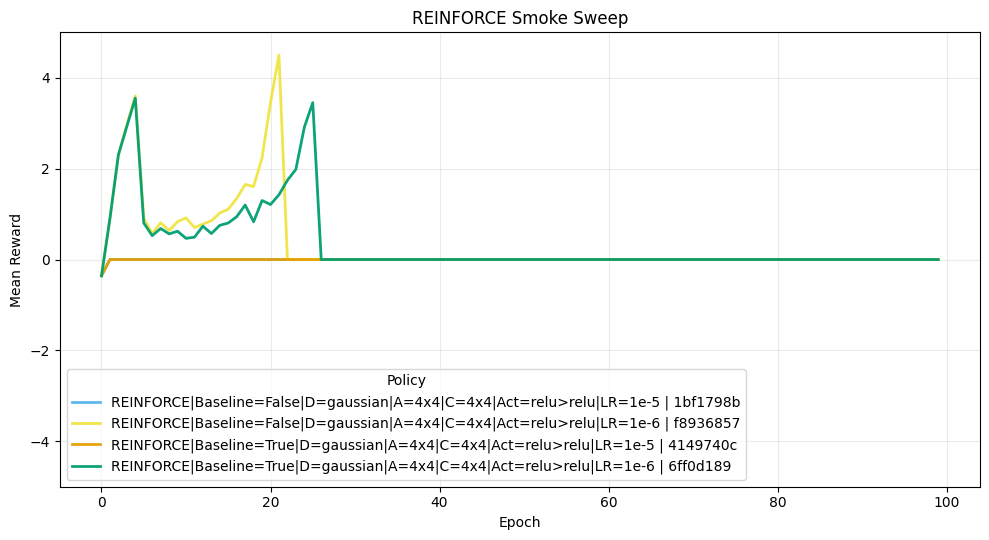

In [61]:
fig, ax = plot_learning_curves(
    learner,
    axes=AxesConfig(ylim=(-5, 5)),
    legend=LegendConfig(loc="best", max_label_chars=96),
    title="REINFORCE Smoke Sweep",
    figsize=(10, 5.5),
)
plt.show()

## Optional Smoothing And Trajectory Variance Band

`std_reward` is the per-epoch trajectory-level standard deviation written by the runner. The band below is not a cross-run confidence interval; it visualizes rollout reward variance for each displayed curve.

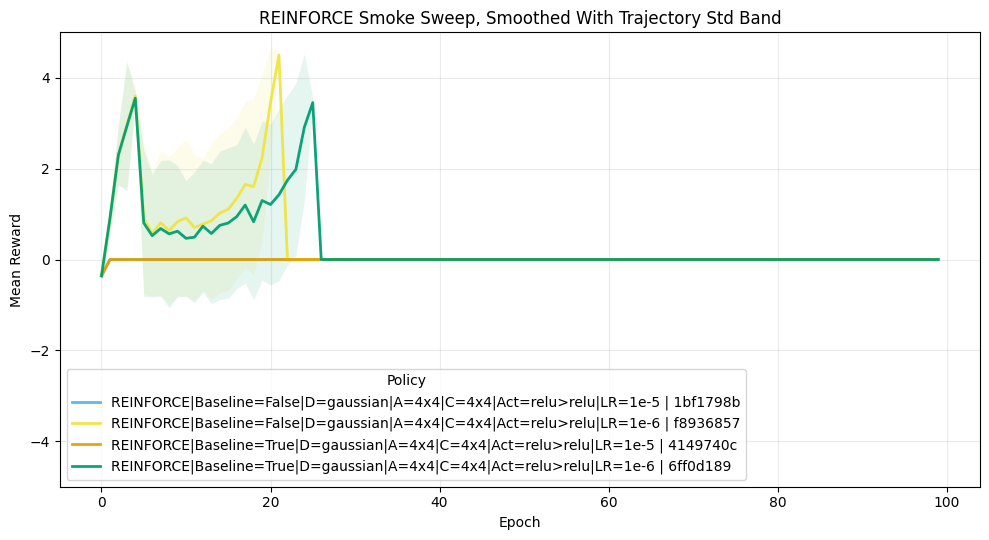

In [64]:
fig, ax = plot_learning_curves(
    learner,
    # The rolling mean is trailing: epoch t averages up to the previous 4 epochs plus t.
    # smoothing=SmoothingConfig(window=5),
    variance=VarianceConfig(column="std_reward", alpha=0.10),
    axes=AxesConfig(ylim=(-5, 5)),
    legend=LegendConfig(loc="best", max_label_chars=96),
    title="REINFORCE Smoke Sweep, Smoothed With Trajectory Std Band",
    figsize=(10, 5.5),
)
plt.show()

## CLI Inspection Equivalent

For quick smoke-test debugging outside a notebook, run:

```bash
make run ARGS="python -m utils.analysis results/reinforce_unified_demo"
```